In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sg
import random
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1 import host_subplot
import mpl_toolkits.axisartist as AA

In [2]:
def plotSignalTime(signal, Fs, Tmax = None):
    t = np.linspace(0, len(signal)/Fs, len(signal))
    plt.plot(t, signal)
    
    # Add empty borders
    if (Tmax):
        if (False): 
            plt.xlim((-Tmax*0.05, Tmax))
        else:
            plt.xlim((0, Tmax))
        
    #plt.stem(signal)
    plt.ylabel('Amplitude')
    plt.xlabel('time, s')
    plt.rc('font', size=15)
    fig = plt.gcf()
    fig.set_size_inches(16, 5)

In [3]:
def plotAmplFreqResp(signal, Fs, Fmax = None, label = None, use_log_scale = False, plot_envelope = False, use_grid = True):   
    fft_signal = np.fft.fft(signal) # make FFT of info signal
    fft_signal = np.fft.fftshift(fft_signal) # shift FFT so that DC (zero frequency) is at center
    N = len(fft_signal)
    if use_log_scale:
        plt.plot(np.linspace(-Fs/2, Fs/2 - Fs/N, N), 10*np.log10(np.abs(fft_signal)), label=label)
        plt.ylabel('Amplitude, dB')
    else:
        plt.plot(np.linspace(-Fs/2, Fs/2 - Fs/N, N), np.abs(fft_signal), label=label)
        plt.ylabel('Amplitude')
    plt.xlabel('Frequency, Hz')
    plt.rc('font', size=15)
    
    # Add empty borders
    if (Fmax):
        plt.xlim((-Fmax, Fmax))
        
    if plot_envelope:
        if use_log_scale:
            db_fft_signal = 10*np.log10(np.abs(fft_signal))
            filt = sg.bessel(1, 1000, 'low', fs=Fs, output='sos')
            db_fft_signal_filtered = sg.sosfilt(filt, db_fft_signal)
            envelope = np.abs(sg.hilbert(db_fft_signal_filtered))
            plt.plot(np.linspace(-Fs/2, Fs/2 - Fs/N, N), envelope, color='r')
    
    if use_grid:
        plt.grid(visible=1, which='both')
        plt.minorticks_on()
        plt.grid(which='major',
                linewidth = 2)
        plt.grid(which='minor', 
                linestyle = ':')
    if label:
        plt.legend()
            
    fig = plt.gcf()
    fig.set_size_inches(16, 3) 

In [4]:
def plotPhaseFreqResp(signal, Fs, Fmax = None, use_grid = True):
    fft_signal = np.fft.fft(signal) # make FFT of info signal
    fft_signal = np.fft.fftshift(fft_signal) # shift FFT so that DC (zero frequency) is at center

    plt.plot(np.linspace(-Fs/2, Fs/2 - Fs/N, N), np.angle(fft_signal))
    plt.ylabel('Phase')
    plt.xlabel('Frequency, Hz')
    plt.rc('font', size=15)

    fig = plt.gcf()
    fig.set_size_inches(16, 5)
    
    # Add empty borders
    if (Fmax):
        plt.xlim((-Fmax, Fmax))
    
    if use_grid:
        plt.grid(visible=1, which='both')
        plt.minorticks_on()
        plt.grid(which='major',
                linewidth = 2)
        plt.grid(which='minor', 
                linestyle = ':')  
        
    fig = plt.gcf()
    fig.set_size_inches(16, 3)

# Digital modulations

Pipeline:

- A1 - Baseband signal: Turn bit sequence into baseband signal. 
- B1 - Pre-modulation filter: If required, filter signal before modulation. (Not included in initial file version)
- C1 - Modulation: Apply baseband signal to a carrier to create modulated signal.
- D - Channel: Pass the signal through noisy channel.  
- C2 - Demodulation: Get baseband signal from the modulated signal - multiply by the carrier. 
- B2 - Demodulation filter: Use an LPF.
- A2 - Detection: Get bit sequence from the baseband signal.

__First try detecting bit sequence with only A-steps. Next, introduce B-steps. Then, C-steps. Finally, D.__

### Reminders
Plot appropriate pictures. Ensure you understand what is going on. Bad graphs reduce your rating
Ask questions if needed.

## A1 - Baseband signal 

In [9]:
Fs = 100000 #samples/s
samples_per_symbol = 100 #samples
symbol_duration = samples_per_symbol / Fs #seconds

bits_per_symbol = 2
alphabet_size = 2**bits_per_symbol
h_alphabet_size = alphabet_size//2

data_symbols = 100 #Use at least 50 bits
data_bits = data_symbols * bits_per_symbol
data = np.random.randint(alphabet_size, size=data_symbols)

baseband_signal = np.kron(data, np.tile(2, samples_per_symbol))
baseband_signal = baseband_signal - alphabet_size + 1 # DC removal
baseband_signal = baseband_signal / np.sqrt((alphabet_size-1) * (alphabet_size+1) /3)  # Normalization 
print(baseband_signal)
t = np.linspace(0, len(baseband_signal)/Fs, len(baseband_signal))

[-1.34164079 -1.34164079 -1.34164079 ... -0.4472136  -0.4472136
 -0.4472136 ]


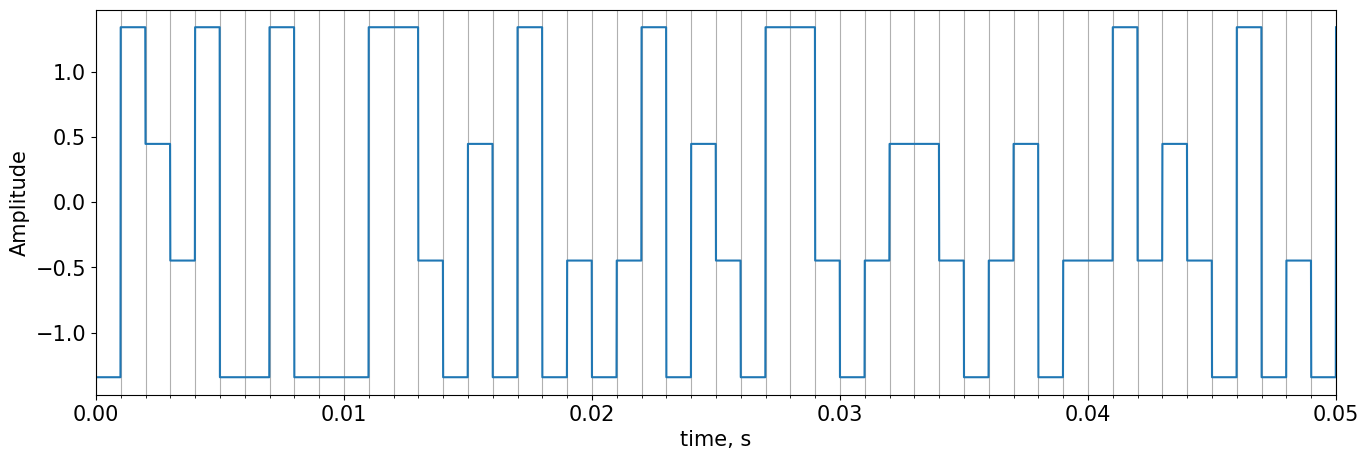

In [10]:
symbols_to_plot = 50
Tmax = symbols_to_plot*samples_per_symbol/Fs
plotSignalTime(baseband_signal, Fs, Tmax)
plt.xticks(np.arange(0, Tmax, step=samples_per_symbol/Fs), minor=True)
plt.grid(which='both', axis='x')

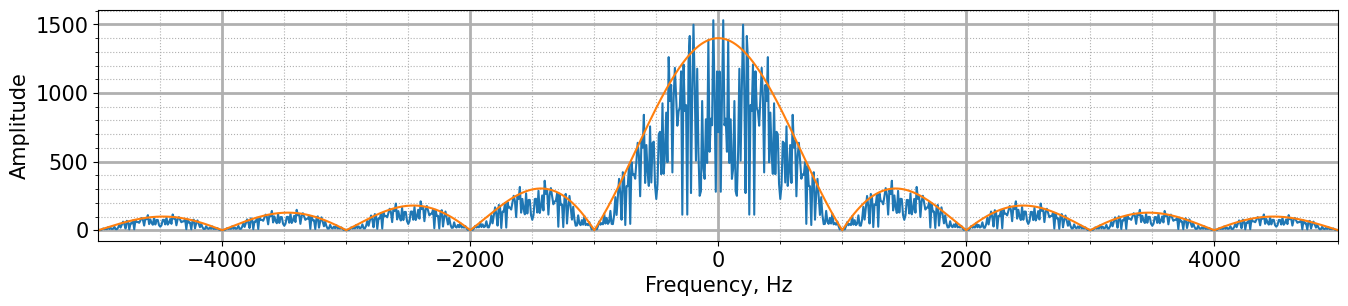

In [11]:
use_log = False
Fmax = Fs/20

#plotAmplFreqResp(baseband_signal, Fs, Fmax, use_log_scale=True, plot_envelope=True)
plotAmplFreqResp(baseband_signal, Fs, Fmax, use_log_scale=use_log)

meander = np.tile(0.5, samples_per_symbol)
meander = np.concatenate([meander, -meander])
meander = np.tile(meander, data_bits//2)
#plotAmplFreqResp(meander, Fs, use_log_scale=use_log)

pulse_signal = np.tile(0, data_bits*samples_per_symbol)
pulse_signal[0:samples_per_symbol] = np.sqrt(data_bits)
plotAmplFreqResp(pulse_signal, Fs, Fmax, use_log_scale=use_log)

if use_log:
    plt.ylim((-10,40))

### Example: Applying ideal LPF to see baseband signal reaction
NOTE: Filtering prior to modulation is not strictly neccesary but used very often. Parameters depend on baseband signal, carrier and channel properties.  

In [12]:
fft_signal = np.fft.fft(baseband_signal)
bw = int(1/symbol_duration)
freq_samples_to_filter = int(bw/Fs*len(fft_signal))

fft_signal[(freq_samples_to_filter):(len(fft_signal)-freq_samples_to_filter)] = 0
filtered_signal = np.real(np.fft.ifft(fft_signal)) #Comment: signal is real. Added np.real() to remove machine error. 

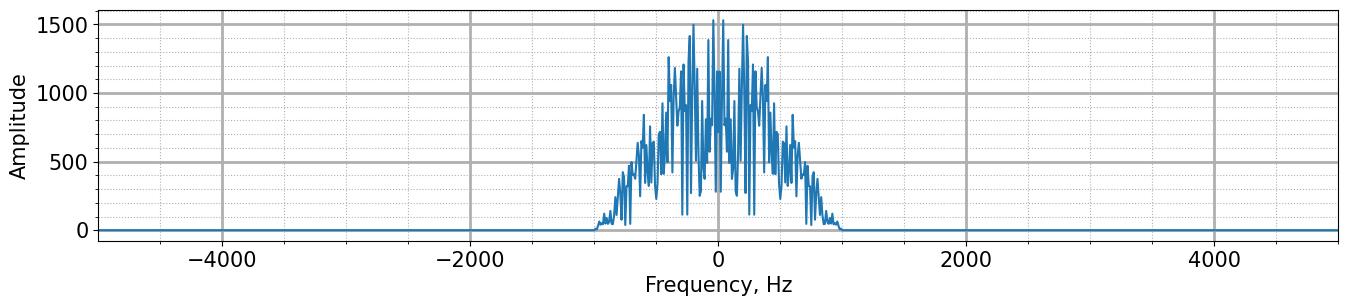

In [13]:
plotAmplFreqResp(filtered_signal, Fs, Fmax)

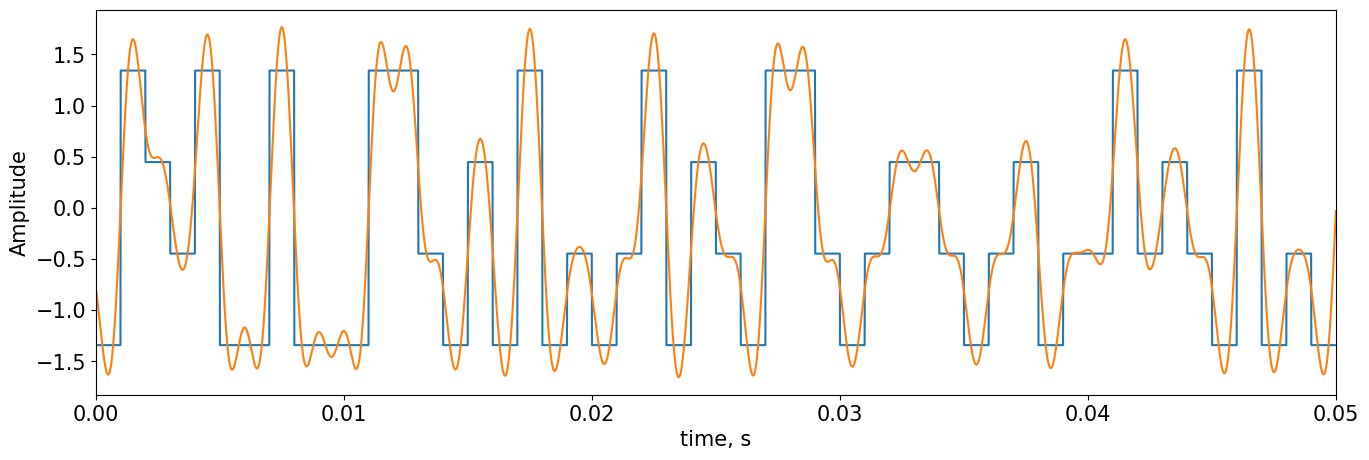

In [14]:
#NOTE: Please plot only COMPREHENCIBLE TIME PLOTS with signals, even for long signals! 50 symbols are recommended.
symbols_to_plot = 50
Tmax = symbols_to_plot*samples_per_symbol/Fs

plotSignalTime(baseband_signal[0:samples_per_symbol*symbols_to_plot], Fs, Tmax)
plotSignalTime(np.real(filtered_signal[0:samples_per_symbol*symbols_to_plot]), Fs, Tmax)

NOTE: Observe the overshoots and undershoots.

## A2 - Detection

### HW1: Make hard-decision decoding for your digital signal. Compare the received bit sequence with the transmitted one: make a bit error rate (BER) calculator.

In [ ]:
# NOTE: After completeing, move B2 section inbetween A1 and A2.

## B2 - Demodulation filter

### HW2: Realize a filter

Recall your number N. Update N = GROUP_SIZE - N.

Select filter x = N mod 6 and realize it:

 0) Butterworth
 1) Chebyshev I
 2) Chebyshev II
 3) Elliptic
 4) Gaussian
 5) Bessel

You may consult yourself, starting from here: https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.iirdesign.html
Use either analog mode or digital mode with correct sampling rate.
If want to change or select another than ones from the list, contact teacher :)

Build your filter according to the following criteria:
 Gp = -1 dB, 
 Gs = -70 dB, 
 fp = 10 kHz, 
 fs = 11 kHz, 
If criteria are too harsh for your filter, contact teacher :)

### HW3: Draw the amplitude-frequency response and phase-frequency response of the filter.
Use format similar to the example from the your last work. 
Add a group delay to the plot.

#### HW4*: Add a proper legend

#### HW5*: Demostrate on the squared amplitude-frequency response that your filter satisfies the criteria. 
Use visual proofs, similar to those in the presentations, t oshow that Gp, Gs, fp, fs are respected. 

In [ ]:
#Note: After completeing, move sections C1 and C2 inbetween A1 and B2. 

## C1 - Modulation

### Example: ASK modulation

In [15]:
def modulateAM(modulator, f_c, f_s, modulation_index, t = []):
    if len(t) == 0:
        t = np.linspace(0, len(modulator)/f_s, len(modulator))
    return (1 + modulation_index * modulator) * np.sin(2*np.pi*f_c*t) #use sin to match sin zeros to symbol change moments.

In [16]:
Fc = 1000 #Hz
ask_signal = modulateAM(baseband_signal, Fc, Fs, 0.3, t)

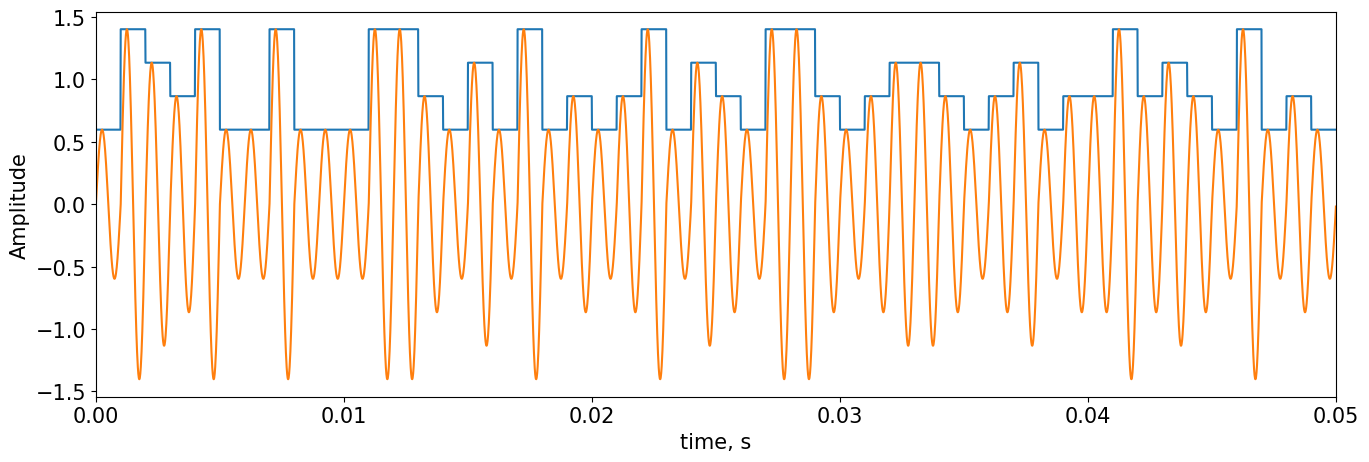

In [18]:
plotSignalTime(1+0.3*baseband_signal[0:samples_per_symbol*symbols_to_plot], Fs, Tmax)
plotSignalTime(ask_signal[0:samples_per_symbol*symbols_to_plot], Fs, Tmax)

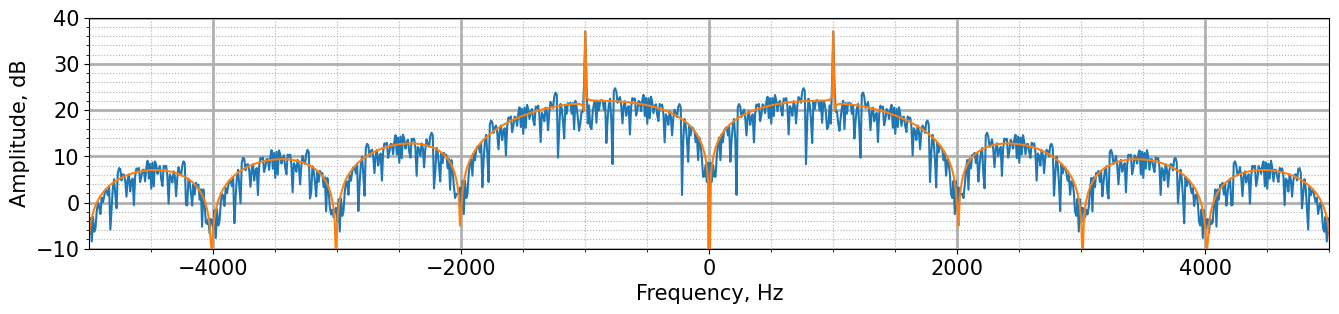

In [31]:
use_log = True
plotAmplFreqResp(ask_signal, Fs, Fmax, use_log_scale=use_log)

ask_pulse_signal = modulateAM(pulse_signal, Fc, Fs, 0.3, t)
plotAmplFreqResp(ask_pulse_signal, Fs, Fmax, use_log_scale=use_log)

if use_log:
    plt.ylim((-10,40))

### HW6: Realize an EASY modulation.
 
Sort your group by last name is alphabetical order. Identify your number N, start with 0.
Select modulation x = N mod 3:

 0) BPSK
 1) QPSK
 2) FSK (select m from [0.5, 1.0, 1.5, ...])
 
NOTE: Make sure your signal parameters and the filter parametes match!

If want to change or select another than ones from the list, contact teacher :)

#### HW7*: Write a short theoretical snippet about your modulation.
Consider main attributes, means of modulation and demodulation. Make references if needed.

### HW8: Realize a NORMAL modulation.

Sort your group by last name is alphabetical order. Identify your number N, start with 0.
Select modulation x = N mod 4:

 0) QBPSK
 1) OQPSK
 2) CPFSK (select m from [0.5, 1.0, 1.5, ...])
 3) X-QAM (select X from [16, 64, 256, ...])
 
If want to change or select another than ones from the list, contact teacher :)

#### HW9*: Write a short theoretical snippet about your modulation.
Consider main attributes, means of modulation and demodulation. Make references if needed.

#### HW10*: For one (**or both) of modulations plot and compare the spectra for different bit rates, but equal baud rates.
NOTE: find the right parameter to change

### HW11: Compare spectra of different modulations, using THE SAME bit sequence. Make conclusions.

## C2 - Demodulation

### HW12: Perform demodulation - multiply by a carrier.
NOTE: Apply LPF to the transmitted signal to remove high-frequency noise on stage B2!

NOTE: You MAY apply passband filter BEFORE multiplying by a carrier to remove extra noise.

In [ ]:
#Note: After completeing, move section D inbetween C1 and C2. 

## D - Channel

### HW: Apply AWGN to the transmitted signal.
Use SNR in dB as input parameter for noise power.

Find three values for SNR, where bit error rate is roughly 8-12%; 0.5-2%; 0.1-0.05%.

## Extra1*: Repeat all process through A1 to A2 for your NORMAL modulation instead of EASY.

## Extra2**: For the demodulated baseband signal, plot the EYE DIAGRAM.

## Extra3**: Effect of filter with non-linear phase
See the task in the presentation about filters. Describe all the results. Ask teacher if any questions.